In [1]:
import mg5qs_imports as qs
from pathlib import Path
import os
import numpy as np

### Changing parameters across two dimensions

This example demonstrates how to change parameters across two (or more) dimensions. 

This example includes:
- setting multiple parameters independently
- generating and showing events
- reassembling results in a coherent order
- plotting results across two dimensions

### Choose a process that generates $\tau$ particles

Namely: <code>generate p p > ta- vt~</code>, which primarily goes through W production with a resonance at the mass of the W boson. 

In [2]:
INPUT_PATH = Path.cwd()/'input' # madgraph cards
# note that for this example, we move to a process which directly generates taus
qs.edit_card(INPUT_PATH, card_name='proc_card_example4.dat')

Text(value='set group_subprocesses Auto', layout=Layout(width='550px'))

Text(value='set ignore_six_quark_processes False', layout=Layout(width='550px'))

Text(value='set low_mem_multicore_nlo_generation False', layout=Layout(width='550px'))

Text(value='set complex_mass_scheme False', layout=Layout(width='550px'))

Text(value='set gauge unitary', layout=Layout(width='550px'))

...

Text(value='define vl~ = ve~ vm~ vt~', layout=Layout(width='550px'))

Text(value='generate p p > ta- vt~', layout=Layout(width='550px'))

Text(value='output EXAMPLE4', layout=Layout(width='550px'))

Button(description='Save', style=ButtonStyle())

Output()

In [3]:
output_name, FRAMEWORK_PATH = qs.run_MG5(INPUT_PATH, proc_card_name='proc_card_example4.dat')

starting process...
done


### Retrieve standard values

The ParamCard class constructs a Python object which is an abstract of MadGraph's param_card.dat. These files hold run information such as particle masses, decay rates, etc. These parameters are accessed at the time of LHE generation.

First, let's construct a ParamCard object and take a look at some of the basic functionality.

In [4]:
card = qs.ParamCard(FRAMEWORK_PATH / 'Cards' / 'param_card.dat') # construct card
card # display card abstract

Abstract of Parameter Card
  /home/leo/output/EXAMPLE4/Cards/param_card.dat
    BLOCKS:
      MASS (17)
      SMINPUTS (3)
      YUKAWA (3)
    DECAY (17)

A ParamCard is constructed from a number of pandas dataframes, which store the parameters directly. We can access these dataframes using ParamCard.dfs().

In [5]:
card.dfs().keys() # list keys of underlying dataframes

dict_keys(['DECAY', 'MASS', 'SMINPUTS', 'YUKAWA'])

In [6]:
card.dfs()['MASS'] # acsess the mass dataframe with standard values 

,key,value,comment
0,5,4.700,MB
1,6,173.000,MT
2,15,1.777,MTA
3,23,91.188,MZ
4,25,125.000,MH
5,1,0.000,d : 0.0
6,2,0.000,u : 0.0
7,3,0.000,s : 0.0
8,4,0.000,c : 0.0
9,11,0.000,e- : 0.0


In this example, we will vary $M_Z$ and $m_{\tau}$ between runs. ParamCard has built-in get and set value functions to more easily access and change specific values. To use these functions, we need to know two things: the block in which the value resides (MASS in this case) and the key within that block. If we want to change the tau mass, we need to know MASS and 15, for example. 

In [7]:
from IPython.display import Math, display

# side trip for fun fact: MadGraph comments show how certain values are calculated
# in particular, the W mass is calculated as a function of Z mass and constants 
W_id = 24
df_masses = card.dfs()['MASS']
df_masses[df_masses['key'] == W_id]['comment'].item() # how is mass for W calculated?

'w+ : cmath.sqrt(MZ__exp__2/2. + cmath.sqrt(MZ__exp__4/4. - (aEW*cmath.pi*MZ__exp__2)/(Gf*sqrt__2)))'

### Set values across two parameters

First, make two lists over which to change the mass values. 

In [8]:
# want to vary both masses in a range where the physics is highly sensitive -- even if wialdly unphysical
Z_id = 23
tau_id = 15
card = qs.ParamCard(FRAMEWORK_PATH / 'Cards' / 'param_card.dat')
m_z, m_tau = card.get_value('MASS', Z_id), card.get_value('MASS', tau_id) # retrieve standard values
MTAU = np.linspace(1,100,5)*1.777 #vary over a wide range of values
MZ = np.linspace(1,10,5)*91.188   #vary over a wide range of values
print(f"tau masses: {MTAU}\n Z masses (to change W mass indirectly: {MZ}")

tau masses: [  1.777    45.75775  89.7385  133.71925 177.7    ]
 Z masses (to change W mass indirectly: [ 91.188 296.361 501.534 706.707 911.88 ]


Second, generate LHEs for resulting 5x5 pairs of parameter values. Since the LHE reads the current parameter_card.dat, we can: change the values, generate LHE, repeat.

**Important: MadGraph produces LHEs in no particular order.** We will have to deal with this later when we want to do something useful with the data. 

**Important: when changing particle masses, the corresponding decay width will not be automatically recalculated unless the entry in the DECAY block is set to -1 explicitly.** I will therefore manually set these values for the W and Z bosons. Notably, I am neglecting to set the tau decay entry to -1 because it is 0.0 by default, and so it is treated as a final-state particle which does not decay (making it non-zero will break the run). 

In [9]:
# generate one set of LHE events for every combination of parameter values
card = qs.ParamCard(FRAMEWORK_PATH / 'Cards' / 'param_card.dat')
card.set_value('DECAY', W_id, -1)
card.set_value('DECAY', Z_id, -1)
for mtau in MTAU:
    card.set_value('MASS', tau_id, mtau)
    for mz in MZ:
        print(f'Generating LHE with: mtau = {mtau} mz = {mz}')
        card.set_value('MASS', Z_id, mz)
        qs.generate_LHE(card, FRAMEWORK_PATH)

Generating LHE with: mtau = 1.777 mz = 91.188
Generating LHE with: mtau = 1.777 mz = 296.361
Generating LHE with: mtau = 1.777 mz = 501.534
Generating LHE with: mtau = 1.777 mz = 706.707
Generating LHE with: mtau = 1.777 mz = 911.88
Generating LHE with: mtau = 45.757749999999994 mz = 91.188
Generating LHE with: mtau = 45.757749999999994 mz = 296.361
Generating LHE with: mtau = 45.757749999999994 mz = 501.534
Generating LHE with: mtau = 45.757749999999994 mz = 706.707
Generating LHE with: mtau = 45.757749999999994 mz = 911.88
Generating LHE with: mtau = 89.7385 mz = 91.188
Generating LHE with: mtau = 89.7385 mz = 296.361
Generating LHE with: mtau = 89.7385 mz = 501.534
Generating LHE with: mtau = 89.7385 mz = 706.707
Generating LHE with: mtau = 89.7385 mz = 911.88
Generating LHE with: mtau = 133.71925 mz = 91.188
Generating LHE with: mtau = 133.71925 mz = 296.361
Generating LHE with: mtau = 133.71925 mz = 501.534
Generating LHE with: mtau = 133.71925 mz = 706.707
Generating LHE with: mt

Third, shower all resulting LHEs. The order is already scrambled, so instead we will reallocate the parameter values with the results by inspecting the return values later. 

In [10]:
qs.pythia_parallel([tau_id], FRAMEWORK_PATH, 'EXAMPLE_CONTOUR', topics='P_mu', size=1000000)

showering: /home/leo/output/EXAMPLE4/Events/run_17/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_16/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_24/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_03/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_19/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_23/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_14/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_15/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_05/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_21/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_06/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_20/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/Events/run_09/unweighted_events.lhe 
showering: /home/leo/output/EXAMPLE4/E

### Retrieve all files in a dictionary (concat=False)

In this use case, results are independent, each representing a run for a unique set of parameters. The <code>qs.unpickle</code> returns a dictionary of results keyed to run name.

In [11]:
data = qs.unpickle('EXAMPLE_CONTOUR', concat=False)
data.keys()

dict_keys(['EXAMPLE4_5', 'EXAMPLE4_17', 'EXAMPLE4_3', 'EXAMPLE4_10', 'EXAMPLE4_11', 'EXAMPLE4_0', 'EXAMPLE4_1', 'EXAMPLE4_22', 'EXAMPLE4_7', 'EXAMPLE4_6', 'EXAMPLE4_18', 'EXAMPLE4_14', 'EXAMPLE4_20', 'EXAMPLE4_21', 'EXAMPLE4_24', 'EXAMPLE4_8', 'EXAMPLE4_12', 'EXAMPLE4_4', 'EXAMPLE4_23', 'EXAMPLE4_16', 'EXAMPLE4_2', 'EXAMPLE4_13', 'EXAMPLE4_19', 'EXAMPLE4_9', 'EXAMPLE4_15'])

### Add $p_{\tau}$ to each set of results:

Each dictionary entry in <code>data</code> contains a tuple (parameters, results) of data type (ParamCard, np.array). For this reason, in the following loop, to access the results dataframe, we use v[1] (the right-hand member of the tuple).

In [12]:
for v in data.values(): # compute pT col in set of results 
    v[1]['pT'] = np.sqrt((v[1]['px']**2)+(v[1]['py']**2)) # v[0] is ParamCard, v[1] is results

### Graph results (in a order of ascending parameters)

To draw a series of plots in which the order respects the parameter values, we must first associate the parameter values with their respective runs, then sort. 

In [13]:
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt

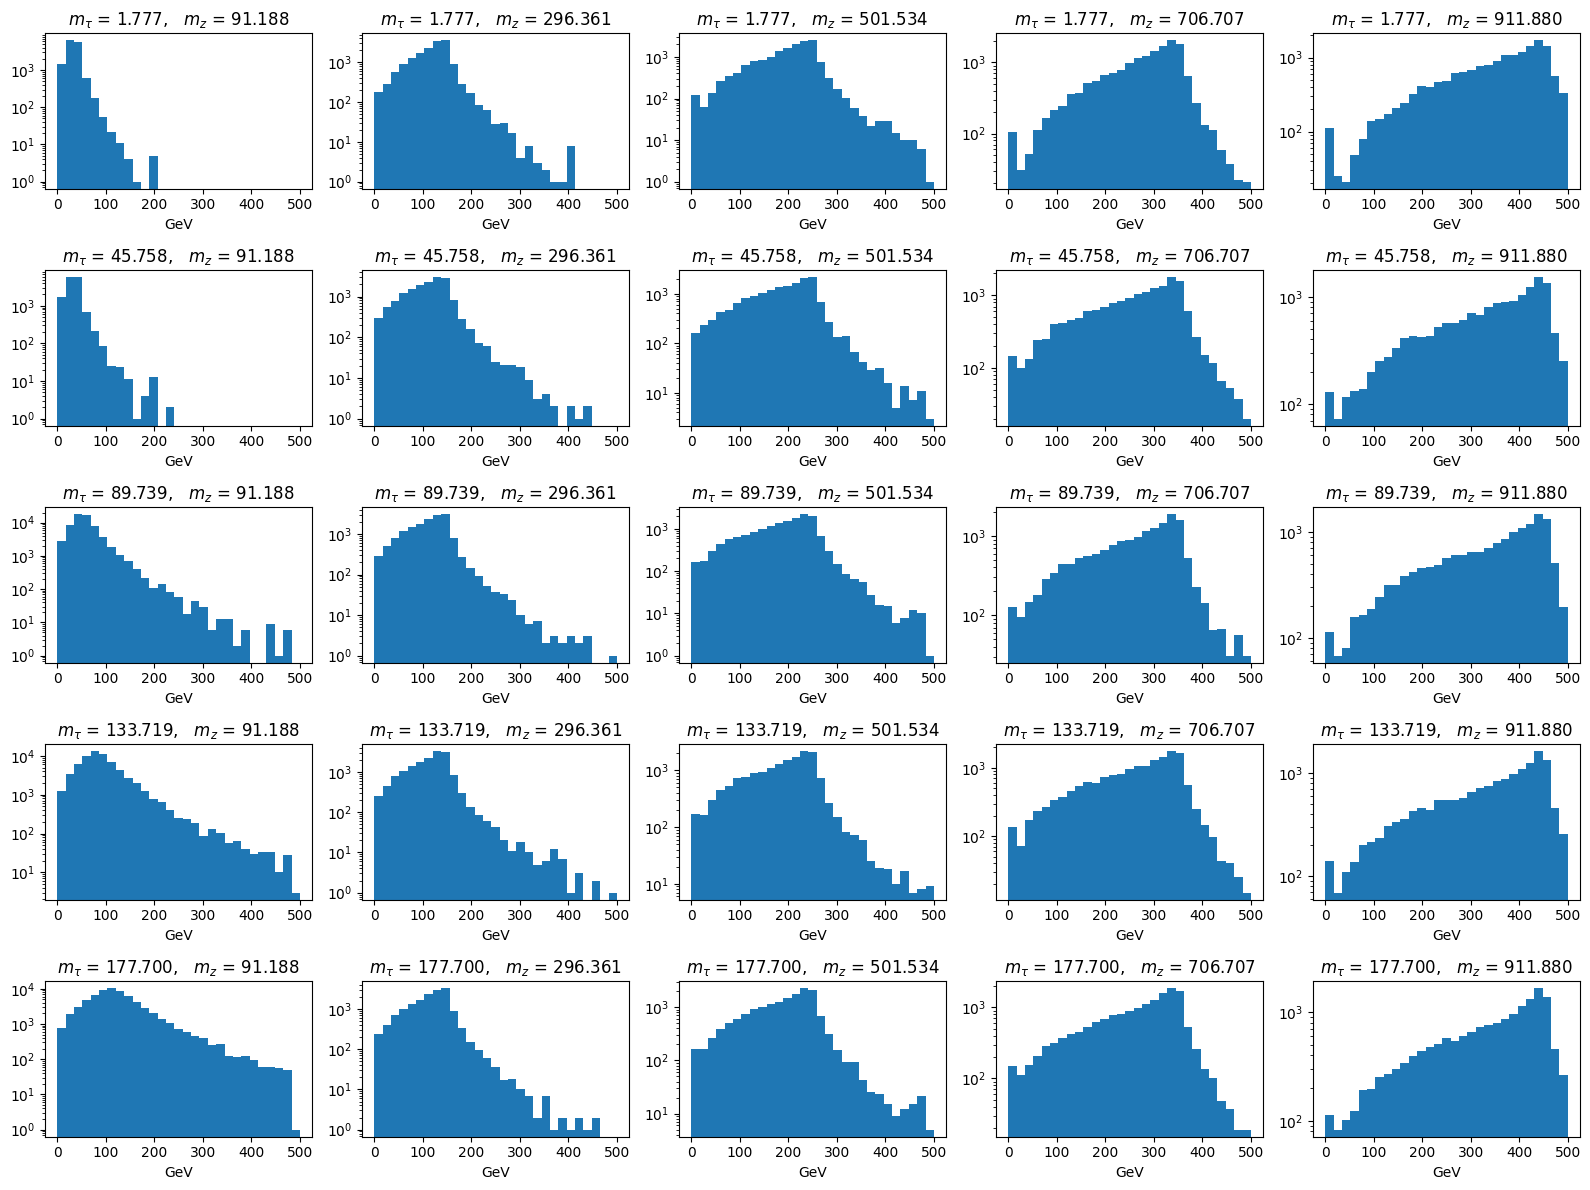

In [14]:
fig, axes = plt.subplots(5, 5, figsize=(16, 12))
axes = axes.flatten()
BINS = np.linspace(0, 500, 30)

# Madgraph produces results in arbitrary order
# inspect each parameter setting to re-establish original order
rows = []
for k in data.keys():
    df_masses = data[k][0].dfs()['MASS']
    m_tau = df_masses[df_masses['key'] == tau_id]['value'].item() # setting for mass of tau
    m_z = df_masses[df_masses['key'] == Z_id]['value'].item() # setting for mass of W
    rows.append((k,m_tau,m_z))
df_runs = pd.DataFrame(rows, columns=['run', 'm_tau', 'm_z'])
df_runs.sort_values(['m_tau','m_z'], inplace = True) # original order
ordered_runs = df_runs['run']

for idx, run in enumerate(ordered_runs):
    pc_df = data[run]
    ax = axes[idx]
    ax.hist(pc_df[1]['pT'], bins=BINS)
    m_tau = pc_df[0].get_value('MASS', tau_id)
    m_z = pc_df[0].get_value('MASS', Z_id)
    ax.set_title(f"$m_\\tau$ = {m_tau:.3f},   $m_z$ = {m_z:.3f}")
    ax.set_xlabel('GeV')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

Note about the results:

These results should not be taken to have any sound physical meaning. The range in which the parameters are being varied is very extreme, and is probably breaking something in some subtle way. The general behavior of the peak shifting to the right with increased $M_Z$ (and therefore $M_W$) is expected, but I have not checked that the amount of shift is physically consistent. 

This example should be treated as a test of the software, and not a sound physical simulation. 

However, the results would be reliable with more reasonable tweaks to the physics. 

Another potentially useful way to use this code structure is to replace multiple plots with a single statistical comparison between each distribution and the SM distribution. It would then be a simple matter to draw a contour plot with the results of the statistical comparisons. 